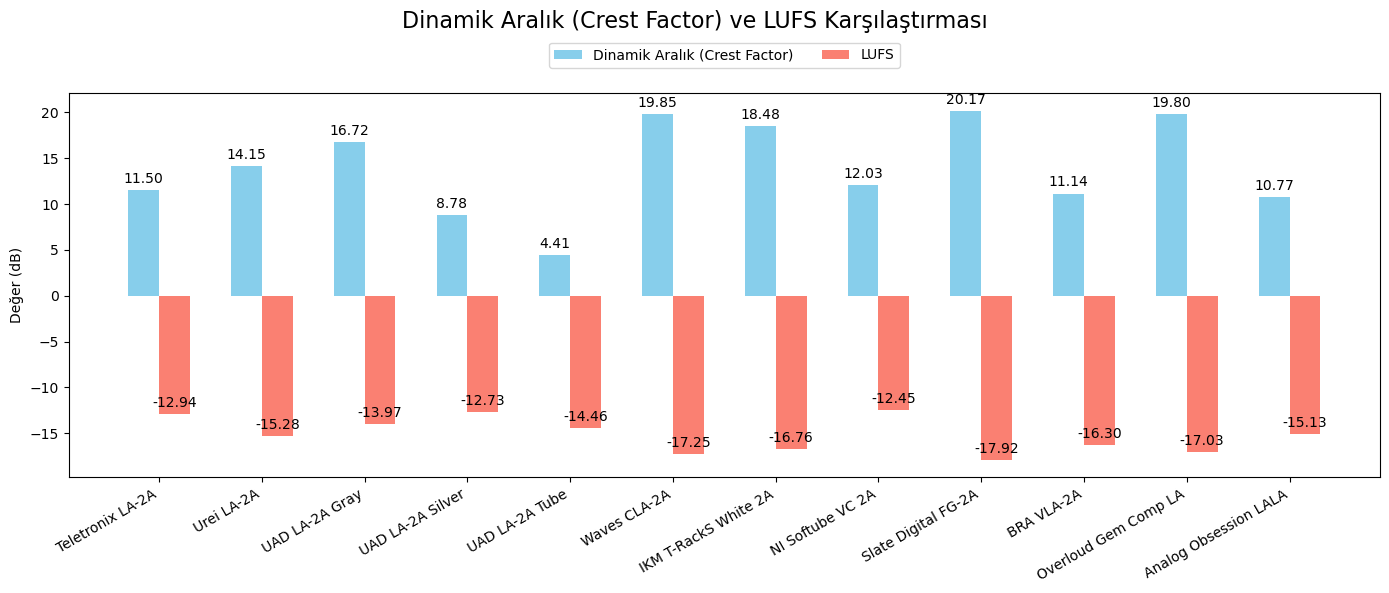

In [1]:
import matplotlib.pyplot as plt  # Grafik işlemleri için
import numpy as np  # Bilimsel hesaplamalar için
import librosa  # Ses işleme için
import librosa.display  
import pyloudnorm as pyln  # LUFS analizi için
from scipy import signal  # Sinyal işleme fonksiyonları için

# Ses dosyalarının yolları
audio_files = [
    "/Users/nazimerensahin/Desktop/processed/teletronix_linear_sweep_sine.wav",
    "/Users/nazimerensahin/Desktop/processed/urei_linear_sweep_sine.wav",
    "/Users/nazimerensahin/Desktop/processed/uad_gray_linear_sweep_sine.wav",
    "/Users/nazimerensahin/Desktop/processed/uad_silver_linear_sweep_sine.wav",
    "/Users/nazimerensahin/Desktop/processed/uad_tube_linear_sweep_sine.wav",
    "/Users/nazimerensahin/Desktop/processed/waves_cla-2a_linear_sweep_sine.wav",
    "/Users/nazimerensahin/Desktop/processed/ikm_white-2a_linear_sweep_sine.wav",
    "/Users/nazimerensahin/Desktop/processed/ni_softube_vc-2a_linear_sweep_sine.wav",
    "/Users/nazimerensahin/Desktop/processed/ss_fg-2a_linear_sweep_sine.wav",
    "/Users/nazimerensahin/Desktop/processed/bra_vla-2a_linear_sweep_sine.wav",
    "/Users/nazimerensahin/Desktop/processed/overloud_gem-comp-la_linear_sweep_sine.wav",
    "/Users/nazimerensahin/Desktop/processed/ao_lala_linear_sweep_sine.wav",
]

# Her dosya için açıklayıcı isimler
audio_labels = [
    "Teletronix LA-2A",
    "Urei LA-2A",
    "UAD LA-2A Gray",
    "UAD LA-2A Silver",
    "UAD LA-2A Tube",
    "Waves CLA-2A",
    "IKM T-RackS White 2A",
    "NI Softube VC 2A",
    "Slate Digital FG-2A",
    "BRA VLA-2A",
    "Overloud Gem Comp LA",
    "Analog Obsession LALA",
]

# LUFS hesaplama aracı
meter = pyln.Meter(44100)  # Örnekleme hızı 44.1 kHz

# Analiz sonuçları için listeler
dr_values = []
lufs_values = []

for file in audio_files:
    # Ses dosyasını yükle
    y, sr = librosa.load(file, sr=None)

    # **1️⃣ Dinamik Aralık (DR) Hesaplama - Crest Factor Yöntemi**
    max_val = np.max(np.abs(y))  # Maksimum genlik değeri
    rms_val = np.sqrt(np.mean(y ** 2))  # RMS (Kök Ortalama Karesi) hesaplama
    
    if rms_val > 0:
        dynamic_range = 20 * np.log10(max_val / rms_val)  # Peak-to-RMS oranı (Crest Factor)
    else:
        dynamic_range = -np.inf  # Sıfıra bölmeyi önlemek için

    dr_values.append(dynamic_range)

    # **2️⃣ LUFS Hesaplama**
    loudness = meter.integrated_loudness(y)
    lufs_values.append(loudness)

# **📊 Grafik Çizimi**
x = np.arange(len(audio_labels))  # X ekseni
width = 0.3  # Çubuk genişliği

fig, ax = plt.subplots(figsize=(14, 6))

# Çubukları çiz
bar1 = ax.bar(x - width / 2, dr_values, width, label='Dinamik Aralık (Crest Factor)', color='skyblue')
bar2 = ax.bar(x + width / 2, lufs_values, width, label='LUFS', color='salmon')

# **Çubukların üzerine değerleri yazdır**
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # Çubuğun üstüne hafif boşluk
                    textcoords="offset points",
                    ha='center', va='bottom')

add_labels(bar1)
add_labels(bar2)

# **Grafik ayarları**
ax.set_ylabel('Değer (dB)')
ax.set_xticks(x)
ax.set_xticklabels(audio_labels, rotation=30, ha='right')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)

# Genel düzenleme ve gösterim
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.suptitle("Dinamik Aralık (Crest Factor) ve LUFS Karşılaştırması", fontsize=16)
plt.show()
